# CryptoStatArb — Research Notebook

**Statistical Arbitrage in Cryptocurrencies** (WSQ Course Project)

Goal: research profitable **momentum and/or reversal** strategies on crypto,
backtest unconstrained, apply realistic execution costs (Binance.US, Tier 1),
and evaluate returns / vol / Sharpe / max drawdown / alpha-beta.

Exchange: [Binance.US](https://www.binance.us/fees)

In [1]:
# --- Core data analysis ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Binance.US API (python-binance) ---
from binance.client import Client
from binance.exceptions import BinanceAPIException

# --- Stats / research ---
import scipy.stats as stats
import statsmodels.api as sm

# --- Utilities ---
import os
import time
import datetime as dt
from pathlib import Path
from importlib.metadata import version

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')
sns.set_theme(style='whitegrid')
%matplotlib inline

print('python-binance', version('python-binance'))
print('pandas', pd.__version__, '| numpy', np.__version__)

python-binance 1.0.37
pandas 2.2.2 | numpy 2.2.4


## Fees & Transaction Costs

Source: <https://www.binance.us/fees> (Tier 1, volume TBD). Commission is tracked
against the live schedule; **bid/ask spread and market-impact costs are asset-dependent**
and set per symbol during research. See [`docs/fees.md`](docs/fees.md).

In [2]:
# --- Binance.US commission (published standard rates, checked 2026-08-27) ---
FEES = {
    'maker_bps': 0.0,      # 0.00%  limit orders that ADD liquidity
    'taker_bps': 2.0,      # 0.02%  market orders that TAKE liquidity
    'bnb_discount': 0.05,  # 5% off maker & taker when fees paid in BNB
}

# Course-project baseline (from ClassProject brief) for cross-checking backtests:
#   market order = 7 bps commission + 13 bps assumed slippage = 20 bps all-in
#   limit order  = 7 bps commission only
PROJECT_COST_ASSUMPTION = {
    'commission_bps': 7.0,
    'slippage_bps': 13.0,
    'market_all_in_bps': 20.0,
    'limit_bps': 7.0,
}

# Asset-dependent costs (half-spread, impact) are filled in per symbol later, e.g.:
#   SYMBOL_TCOSTS = {'BTCUSDT': {'half_spread_bps': ..., 'impact_bps': ...}, ...}
SYMBOL_TCOSTS = {}

def bps(x):
    """basis points -> decimal (e.g. 20 -> 0.0020)."""
    return x / 1e4

FEES

{'maker_bps': 0.0, 'taker_bps': 2.0, 'bnb_discount': 0.05}

## Data

Two paths: (1) load the week-3 lecture dataset already saved locally, or
(2) pull fresh OHLCV from Binance.US via `python-binance`. Public market data
(klines) needs **no API key**; keys are only required for account/trading endpoints
and must live in a gitignored `.env` — never commit them.

In [3]:
# Option 2 — pull fresh OHLCV from Binance.US (public market data, no API key needed)
# Same course pattern as the week-3 PriceData notebook: Client(tld='US') + format_binance().
from datetime import datetime

client = Client(tld='US')   # Binance.US endpoints (US users)

def format_binance(data):
    cols = ['open_time', 'open', 'high', 'low', 'close', 'volume', 'close_time',
            'quote_volume', 'num_trades', 'taker_base_volume', 'taker_quote_volume', 'ignore']
    df = pd.DataFrame(data, columns=cols)
    # POSIX ms -> datetime
    df['open_time']  = df['open_time'].map(lambda x: datetime.fromtimestamp(x / 1000))
    df['close_time'] = df['close_time'].map(lambda x: datetime.fromtimestamp(x / 1000))
    for c in ['open', 'high', 'low', 'close', 'volume',
              'quote_volume', 'taker_base_volume', 'taker_quote_volume']:
        df[c] = df[c].astype(float)
    return df

# quick check — one symbol
btc = format_binance(client.get_historical_klines('BTCUSDT', '1d', '1 Jan 2019'))
btc.tail()

,open_time,open,high,low,close,volume,close_time,quote_volume,num_trades,taker_base_volume,taker_quote_volume,ignore
2526,2026-08-22 17:00:00,"77,096.450000","78,039.020000","75,576.700000","77,727.000000",79.158540,2026-08-23 16:59:59.999,"6,106,667.212127",8217,36.348300,"2,801,231.352186",0
2527,2026-08-23 17:00:00,"77,746.170000","79,975.000000","76,684.890000","78,979.640000",120.492320,2026-08-24 16:59:59.999,"9,466,731.012179",12776,63.838710,"5,015,044.808588",0
2528,2026-08-24 17:00:00,"78,980.570000","81,261.270000","77,874.270000","78,572.170000",155.380220,2026-08-25 16:59:59.999,"12,392,706.438878",12381,67.419590,"5,383,849.352264",0
2529,2026-08-25 17:00:00,"78,562.190000","79,235.910000","77,626.560000","79,033.170000",51.499850,2026-08-26 16:59:59.999,"4,039,341.906348",6428,22.603240,"1,772,382.886721",0
2530,2026-08-26 17:00:00,"78,980.280000","80,814.570000","78,600.000000","80,000.660000",41.192840,2026-08-27 16:59:59.999,"3,286,954.198470",6501,20.751090,"1,658,279.630181",0


---
# Reversal Study — Intraday ACF Across Holding Intervals

**Hypothesis:** crypto shows *reversal* (negative return autocorrelation) at short intraday horizons.

**Method:** for each holding interval *b* (1,2,3,4,6,8,12h — all divide 24h for clean
midnight-UTC-aligned, non-overlapping bars), resample close-to-close **log returns**, then
compute the autocorrelation at lags 1…L where **L ≈ 30/b** (holds the wall-clock window ~30h
constant across frequencies). Output: a `(bar size × lag)` map per ticker, plus the
cross-sectional average.

- Negative autocorr → reversal; positive → momentum.
- Non-overlapping bars ⇒ no overlap-induced SE bias.
- Significance overlay: Bartlett white-noise band ±1.96/√N.
- **No t-costs applied here** (raw effect only). Bid-ask bounce can inflate the very shortest
  lags — interpret lag-1 cautiously.

**Universe:** 19 Binance.US USDT pairs (original 9 + SOL, DOT, LTC, BCH, MATIC, UNI, ATOM, NEAR, ICP, SHIB).

In [4]:
# --- Cell 4: fetch 3 years of HOURLY close for the study universe (UTC-aligned) ---
DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)   # self-contained: no dependency on any other cell

UNIVERSE = ['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'ADAUSDT', 'XRPUSDT', 'XLMUSDT',
            'DOGEUSDT', 'LINKUSDT', 'AVAXUSDT', 'SOLUSDT', 'DOTUSDT', 'LTCUSDT',
            'BCHUSDT', 'UNIUSDT', 'ATOMUSDT', 'NEARUSDT', 'ICPUSDT', 'SHIBUSDT']
START = '2023-08-27'   # ~3 years back

def fetch_hourly_close(symbol, start=START):
    """Hourly close as a UTC-indexed Series (UTC matters for midnight-aligned resampling)."""
    raw = client.get_historical_klines(symbol, '1h', start)
    cols = ['open_time', 'open', 'high', 'low', 'close', 'volume', 'close_time',
            'quote_volume', 'num_trades', 'taker_base_volume', 'taker_quote_volume', 'ignore']
    df = pd.DataFrame(raw, columns=cols)
    df['open_time'] = pd.to_datetime(df['open_time'], unit='ms', utc=True)
    return df.set_index('open_time')['close'].astype(float)

CACHE = DATA_DIR / 'binance_us_hourly_close.pk'
if CACHE.exists():
    px_h = pd.read_pickle(CACHE)                      # reuse cached pull
else:
    px_h = pd.DataFrame({s: fetch_hourly_close(s) for s in UNIVERSE}).sort_index()
    px_h.to_pickle(CACHE)

px_h.index.name = 'open_time_utc'
print(px_h.shape, '|', px_h.index.min(), '->', px_h.index.max())

# Data-quality: flag tickers with large gaps (e.g. MATIC->POL rebrand mid-2024)
coverage = (1 - px_h.isna().mean()).sort_values()
print('lowest coverage:', {k: round(v, 3) for k, v in coverage.head(3).items()})
px_h.tail()

(26325, 19) | 2023-08-27 00:00:00+00:00 -> 2026-08-27 20:00:00+00:00
lowest coverage: {'MATICUSDT': 0.458, 'BTCUSDT': 1.0, 'NEARUSDT': 1.0}


,BTCUSDT,ETHUSDT,BNBUSDT,ADAUSDT,XRPUSDT,XLMUSDT,DOGEUSDT,LINKUSDT,AVAXUSDT,SOLUSDT,DOTUSDT,LTCUSDT,BCHUSDT,MATICUSDT,UNIUSDT,ATOMUSDT,NEARUSDT,ICPUSDT,SHIBUSDT
open_time_utc,,,,,,,,,,,,,,,,,,,
2026-08-27 16:00:00+00:00,"80,398.750000","2,523.130000",712.800000,0.216050,1.466400,0.188350,0.089380,11.883000,7.532000,108.900000,0.887000,50.330000,272.600000,NaN,4.600000,1.561000,1.934000,2.463000,0.000005
2026-08-27 17:00:00+00:00,"80,474.440000","2,519.960000",710.600000,0.215480,1.459700,0.187790,0.089200,11.932000,7.521000,108.330000,0.892000,50.140000,272.600000,NaN,4.606000,1.523000,1.925000,2.455000,0.000005
2026-08-27 18:00:00+00:00,"80,148.000000","2,506.080000",710.490000,0.214110,1.451100,0.186820,0.088630,11.865000,7.492000,108.260000,0.881000,49.800000,267.900000,NaN,4.530000,1.523000,1.902000,2.449000,0.000005
2026-08-27 19:00:00+00:00,"79,921.000000","2,498.160000",711.090000,0.214400,1.456000,0.186560,0.088520,11.854000,7.495000,109.400000,0.881000,50.060000,269.200000,NaN,4.603000,1.523000,1.955000,2.437000,0.000005
2026-08-27 20:00:00+00:00,"79,991.030000","2,499.300000",710.010000,0.213220,1.453100,0.187100,0.088520,11.856000,7.492000,109.590000,0.881000,49.930000,269.900000,NaN,4.603000,1.523000,1.955000,2.443000,0.000005


In [5]:
# --- Next cell: resample to non-overlapping b-hour bars, compute the lag-scan ACF ---
BARS = [1, 2, 3, 4, 6, 8, 12]   # holding intervals (h); all divide 24 -> clean midnight-UTC bars
WINDOW_H = 30                    # wall-clock window to keep ~constant: L_b = round(30/b)

def bar_log_returns(px, b):
    """Non-overlapping b-hour close-to-close log returns, aligned to midnight UTC."""
    bars = px.resample(f'{b}h', origin='start_day', label='right', closed='right').last()
    return np.log(bars).diff()

def acf(x, L):
    """Autocorrelation at lags 1..L for one series; returns (acf_array, n_obs)."""
    x = x.dropna()
    xm = (x - x.mean()).values
    denom = (xm ** 2).sum()
    out = [(xm[l:] * xm[:-l]).sum() / denom if denom > 0 else np.nan for l in range(1, L + 1)]
    return np.array(out), len(x)

detail, mean_acf, bartlett = {}, {}, {}
for b in BARS:
    L = max(1, 30)
    R = bar_log_returns(px_h, b)
    per, Ns = {}, []
    for c in R.columns:
        a, n = acf(R[c], L)
        per[c] = a
        Ns.append(n)
    d = pd.DataFrame(per, index=pd.RangeIndex(1, L + 1, name='lag'))
    detail[b] = d                              # lag x ticker
    mean_acf[b] = d.mean(axis=1)               # cross-sectional mean ACF
    bartlett[b] = 1.96 / np.sqrt(int(np.median(Ns)))   # per-ticker 95% white-noise band

# Headline: (lag x bar size) grid of cross-sectionally-averaged autocorrelation.
# Negative -> reversal, positive -> momentum.
acf_grid = pd.DataFrame(mean_acf)
acf_grid.columns.name = 'bar_h'
print('Per-ticker Bartlett 95% band (|acf| above this is ~significant for a single asset):')
print({b: round(v, 4) for b, v in bartlett.items()})
acf_grid.round(4)

Per-ticker Bartlett 95% band (|acf| above this is ~significant for a single asset):
{1: np.float64(0.0121), 2: np.float64(0.0171), 3: np.float64(0.0209), 4: np.float64(0.0242), 6: np.float64(0.0296), 8: np.float64(0.0342), 12: np.float64(0.0418)}


bar_h,1,2,3,4,6,8,12
lag,,,,,,,
1,-0.052600,-0.060100,-0.043600,-0.048800,-0.016100,-0.036900,-0.014200
2,-0.023500,-0.004500,0.009300,0.000200,-0.011100,0.018500,-0.013300
3,-0.007000,0.003400,-0.011000,-0.000600,0.003900,-0.036400,0.017700
4,0.004100,-0.008800,-0.004500,0.012000,-0.033600,0.043500,-0.016000
5,-0.001600,-0.007700,0.011800,-0.013100,0.012700,-0.001500,0.023300
6,-0.001500,0.000400,0.002500,-0.019500,0.012800,-0.006800,-0.036100
7,-0.002300,0.000600,-0.022500,0.004900,0.010600,-0.010500,0.012600
8,-0.000900,0.012800,-0.023400,0.018200,-0.002400,0.025100,0.016800
9,-0.004500,0.004400,0.013400,-0.005300,-0.002000,-0.026800,-0.003500


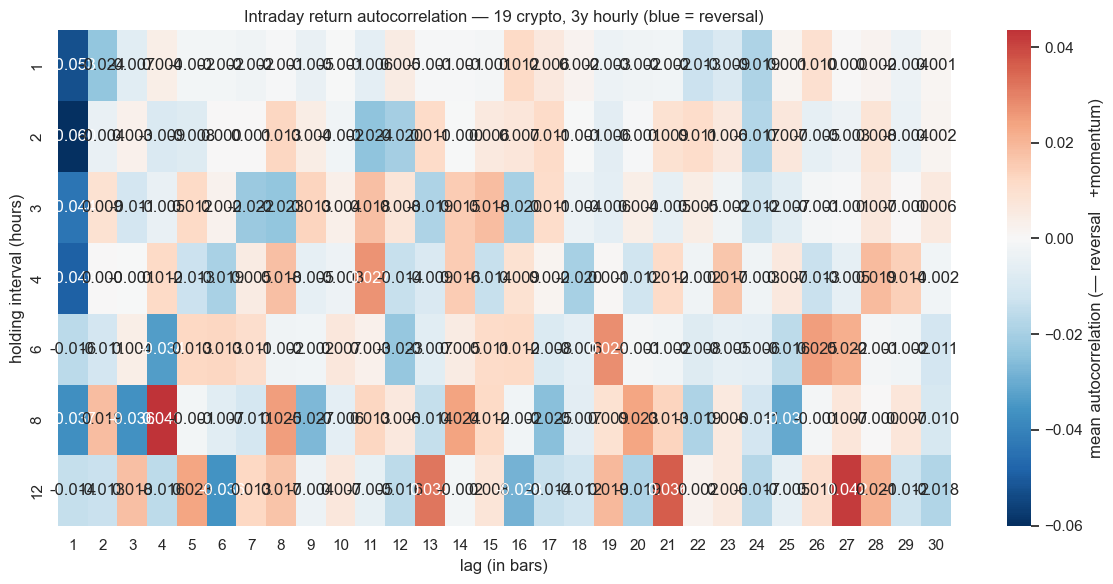

Strongest reversal (most negative mean ACF):
 bar_h  lag       acf
     2    1 -0.060128
     1    1 -0.052615
     4    1 -0.048833
     3    1 -0.043606
     8    1 -0.036928
     8    3 -0.036354
    12    6 -0.036087
     6    4 -0.033636


In [6]:
# --- Visualize: reversal (blue) vs momentum (red) across bar size x lag ---
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(acf_grid.T, center=0, cmap='RdBu_r', annot=True, fmt='.3f',
            cbar_kws={'label': 'mean autocorrelation (— reversal   +momentum)'}, ax=ax)
ax.set_xlabel('lag (in bars)')
ax.set_ylabel('holding interval (hours)')
ax.set_title('Intraday return autocorrelation — 19 crypto, 3y hourly (blue = reversal)')
plt.tight_layout()
plt.show()

# Where is the reversal strongest? Most-negative average-ACF cells:
flat = acf_grid.T.stack().rename('acf').reset_index()
flat.columns = ['bar_h', 'lag', 'acf']
print('Strongest reversal (most negative mean ACF):')
print(flat.nsmallest(8, 'acf').to_string(index=False))

In [ ]:
# --- Isolate lag-1 reversal per ticker, 1-4h holding intervals, with significance ---
# More negative = stronger single-bar reversal. detail[b].loc[1] = lag-1 ACF across tickers.
from scipy.stats import norm

lag1 = pd.DataFrame({f'{b}h': detail[b].loc[1] for b in [1, 2, 3, 4]})
lag1['avg_1_4h'] = lag1.mean(axis=1)

# Significance at the 1h base frequency (largest sample). Under the white-noise null,
# SE(rho) ~ 1/sqrt(N)  =>  t = rho * sqrt(N),  two-sided p-value from the normal.
N_1h = bar_log_returns(px_h, 1).notna().sum()          # per-ticker obs at 1h
lag1['t_1h'] = lag1['1h'] * np.sqrt(N_1h)
lag1['p_1h'] = 2 * norm.sf(lag1['t_1h'].abs())
stars = lambda p: '***' if p < 1e-3 else '**' if p < 1e-2 else '*' if p < 5e-2 else 'ns'
lag1['sig'] = lag1['p_1h'].map(stars)

lag1 = lag1.sort_values('avg_1_4h')                     # strongest reversal (most negative) on top
lag1.index.name = 'ticker'
print(f"1h-bar Bartlett 95% band: +/-{bartlett[1]:.4f}   (*** p<.001  ** p<.01  * p<.05  ns not sig.)")
lag1.round({'1h': 4, '2h': 4, '3h': 4, '4h': 4, 'avg_1_4h': 4, 't_1h': 1, 'p_1h': 4})